# 05 — Regresión logística para AndinaLog 03B

## Objetivo

Entrenar un modelo sencillo que estime si ocurrirá una desviación térmica durante los siguientes 60 minutos.

El modelo utilizará únicamente las cinco variables solicitadas:

1. Temperatura actual.
2. Humedad actual.
3. Desviación térmica actual.
4. Temperatura anterior.
5. Variación de temperatura durante los últimos 30 minutos.

Los viajes se separarán entre entrenamiento y prueba para evitar que lecturas consecutivas del mismo recorrido aparezcan en ambos grupos.

## 1. Librerías y configuración

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

CONFIG = {
    "ruta_gold": Path("outputs/03_silver_gold_iot/andinalog_iot_modelado_gold.csv"),
    "carpeta_salida": Path("outputs/05_regresion_logistica_iot"),
    "semilla": 42,
    "proporcion_prueba": 0.20,
    "umbral": 0.50,
    "objetivo": "desviacion_proximos_60min_flag",
    "grupo": "viaje_id",
    "predictores": [
        "temperatura_cabina_c",
        "humedad_cabina_pct",
        "desviacion_termica_flag",
        "temperatura_anterior",
        "variacion_temperatura_30min",
    ],
}

CONFIG["carpeta_salida"].mkdir(parents=True, exist_ok=True)
RUTA_INFORME = CONFIG["carpeta_salida"] / "Informe_05_Regresion_Logistica_IoT.md"

print("Semilla:", CONFIG["semilla"])
print("Proporción de prueba:", CONFIG["proporcion_prueba"])
print("Umbral de clasificación:", CONFIG["umbral"])

Semilla: 42
Proporción de prueba: 0.2
Umbral de clasificación: 0.5


### Explicación sencilla

La semilla permite repetir exactamente la misma división. El umbral 0,50 significa que el modelo predice una desviación cuando su probabilidad estimada es igual o superior al 50 %.

## 2. Carga y selección de datos

In [2]:
ruta_gold = CONFIG["ruta_gold"]
if not ruta_gold.exists():
    alternativa = Path("/content/andinalog_iot_modelado_gold.csv")
    if alternativa.exists():
        ruta_gold = alternativa
    else:
        raise FileNotFoundError("No se encontró el CSV Gold. Ajusta CONFIG['ruta_gold'].")

gold = pd.read_csv(ruta_gold)
requeridas = CONFIG["predictores"] + [CONFIG["objetivo"], CONFIG["grupo"], "ventana_objetivo_evaluable"]
faltantes = [c for c in requeridas if c not in gold.columns]
if faltantes:
    raise ValueError(f"Faltan columnas necesarias: {faltantes}")

# Solo se modelan las filas cuyo futuro de 60 minutos pudo observarse.
modelado = gold.loc[
    gold["ventana_objetivo_evaluable"].eq(True)
    & gold[CONFIG["objetivo"]].notna()
].copy()

X = modelado[CONFIG["predictores"]]
y = modelado[CONFIG["objetivo"]].astype(int)
grupos = modelado[CONFIG["grupo"]]

print(f"Filas Gold: {len(gold):,}")
print(f"Filas utilizables para el modelo: {len(modelado):,}")
print(f"Viajes utilizables: {grupos.nunique():,}")
print("Predictores:", CONFIG["predictores"])
display(X.isna().sum().rename("faltantes").to_frame())

Filas Gold: 28,465
Filas utilizables para el modelo: 25,797
Viajes utilizables: 1,200
Predictores: ['temperatura_cabina_c', 'humedad_cabina_pct', 'desviacion_termica_flag', 'temperatura_anterior', 'variacion_temperatura_30min']


,faltantes
temperatura_cabina_c,0
humedad_cabina_pct,0
desviacion_termica_flag,0
temperatura_anterior,1188
variacion_temperatura_30min,1452


### Explicación sencilla

Las últimas lecturas sin una hora futura completa no pueden indicar qué ocurrió después; por eso no se usan para entrenar ni evaluar. Los faltantes de las variables históricas se completarán dentro del proceso de entrenamiento, sin consultar la prueba.

## 3. Balance del objetivo

In [3]:
balance = y.value_counts().reindex([0, 1], fill_value=0)
prevalencia_total = y.mean()
display(pd.DataFrame({
    "lecturas": balance,
    "porcentaje": (balance / len(y) * 100).round(2),
}))
print(f"Desviaciones futuras: {balance[1]:,} de {len(y):,} ({prevalencia_total * 100:.2f}%).")

,lecturas,porcentaje
desviacion_proximos_60min_flag,,
0,24501,94.98
1,1296,5.02


Desviaciones futuras: 1,296 de 25,797 (5.02%).


### Interpretación sencilla

La clase positiva es poco frecuente. Un modelo que siempre responda “no habrá desviación” acertaría muchas filas, pero nunca detectaría un problema. Por eso no evaluaremos el modelo solamente con el porcentaje total de aciertos.

## 4. Separación por viaje

In [4]:
divisor = GroupShuffleSplit(
    n_splits=1,
    test_size=CONFIG["proporcion_prueba"],
    random_state=CONFIG["semilla"],
)
indices_train, indices_test = next(divisor.split(X, y, groups=grupos))

X_train, X_test = X.iloc[indices_train].copy(), X.iloc[indices_test].copy()
y_train, y_test = y.iloc[indices_train].copy(), y.iloc[indices_test].copy()
grupos_train = grupos.iloc[indices_train]
grupos_test = grupos.iloc[indices_test]

viajes_compartidos = set(grupos_train) & set(grupos_test)
resumen_split = pd.DataFrame({
    "partición": ["Entrenamiento", "Prueba"],
    "filas": [len(X_train), len(X_test)],
    "viajes": [grupos_train.nunique(), grupos_test.nunique()],
    "positivos": [int(y_train.sum()), int(y_test.sum())],
    "prevalencia_pct": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)],
})
display(resumen_split)
print("Viajes compartidos entre entrenamiento y prueba:", len(viajes_compartidos))

if viajes_compartidos:
    raise AssertionError("La división mezcló viajes entre entrenamiento y prueba.")
if y_test.nunique() < 2:
    raise AssertionError("La prueba no contiene las dos clases y no permite evaluar el modelo.")

,partición,filas,viajes,positivos,prevalencia_pct
0,Entrenamiento,20623,960,1018,4.94
1,Prueba,5174,240,278,5.37


Viajes compartidos entre entrenamiento y prueba: 0


### Interpretación sencilla

Cada viaje pertenece por completo a una sola partición. De esta forma, el modelo se evalúa con recorridos que no vio durante el aprendizaje.

## 5. Preparación y entrenamiento

In [5]:
modelo = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalado", StandardScaler()),
    ("regresion", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=CONFIG["semilla"],
    )),
])

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")
print("Imputación: mediana aprendida solo con entrenamiento.")
print("Escalado: promedio y desviación aprendidos solo con entrenamiento.")
print("Balance: cada clase recibe un peso inverso a su frecuencia.")

Modelo entrenado correctamente.
Imputación: mediana aprendida solo con entrenamiento.
Escalado: promedio y desviación aprendidos solo con entrenamiento.
Balance: cada clase recibe un peso inverso a su frecuencia.


### Explicación sencilla

- La imputación completa los pocos antecedentes faltantes usando únicamente el entrenamiento.
- El escalado coloca las variables en una escala comparable.
- La ponderación evita que el modelo ignore la clase poco frecuente.
- Todo está contenido en un `Pipeline`, por lo que la prueba no participa en el aprendizaje.

## 6. Predicciones y línea base

In [6]:
probabilidades = modelo.predict_proba(X_test)[:, 1]
predicciones = (probabilidades >= CONFIG["umbral"]).astype(int)

# Línea base adecuada al desbalance: siempre predice la clase mayoritaria (0).
predicciones_base = np.zeros(len(y_test), dtype=int)
probabilidades_base = np.zeros(len(y_test), dtype=float)

print("Predicciones positivas del modelo:", int(predicciones.sum()))
print("Predicciones positivas de la línea base:", int(predicciones_base.sum()))

Predicciones positivas del modelo: 461
Predicciones positivas de la línea base: 0


## 7. Métricas finales sobre prueba

In [7]:
def calcular_metricas(nombre, y_real, y_pred, probabilidades_pred):
    return {
        "modelo": nombre,
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1": f1_score(y_real, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_real, probabilidades_pred),
        "pr_auc": average_precision_score(y_real, probabilidades_pred),
    }

metricas = pd.DataFrame([
    calcular_metricas("Regresión logística", y_test, predicciones, probabilidades),
    calcular_metricas("Línea base: siempre 0", y_test, predicciones_base, probabilidades_base),
]).set_index("modelo")

display((metricas * 100).round(2).rename(columns=lambda c: c + " (%)"))
print(f"Prevalencia positiva en prueba: {y_test.mean() * 100:.2f}%")

,precision (%),recall (%),f1 (%),roc_auc (%),pr_auc (%)
modelo,,,,,
Regresión logística,28.2,46.76,35.18,74.89,37.32
Línea base: siempre 0,0.0,0.00,0.00,50.00,5.37


Prevalencia positiva en prueba: 5.37%


### Cómo leer las métricas

- **Precisión:** de todas las alertas generadas, qué porcentaje correspondía a una desviación real.
- **Recall o sensibilidad:** de todas las desviaciones reales, qué porcentaje fue detectado.
- **F1:** equilibrio entre precisión y recall.
- **ROC AUC:** capacidad general para ordenar casos de menor a mayor riesgo.
- **PR AUC:** resumen especialmente útil cuando la clase positiva es poco frecuente.

In [8]:
print("Interpretación sencilla")
print(f"- El modelo detecta {metricas.loc['Regresión logística', 'recall'] * 100:.2f}% de las desviaciones reales.")
print(f"- De las alertas emitidas, {metricas.loc['Regresión logística', 'precision'] * 100:.2f}% son correctas.")
print(f"- Su F1 es {metricas.loc['Regresión logística', 'f1'] * 100:.2f}%.")
print(f"- Su ROC AUC es {metricas.loc['Regresión logística', 'roc_auc']:.3f} y su PR AUC es {metricas.loc['Regresión logística', 'pr_auc']:.3f}.")
print("- La línea base no detecta ninguna desviación, por lo que su recall y F1 son 0%.")

Interpretación sencilla
- El modelo detecta 46.76% de las desviaciones reales.
- De las alertas emitidas, 28.20% son correctas.
- Su F1 es 35.18%.
- Su ROC AUC es 0.749 y su PR AUC es 0.373.
- La línea base no detecta ninguna desviación, por lo que su recall y F1 son 0%.


## 8. Matriz de confusión

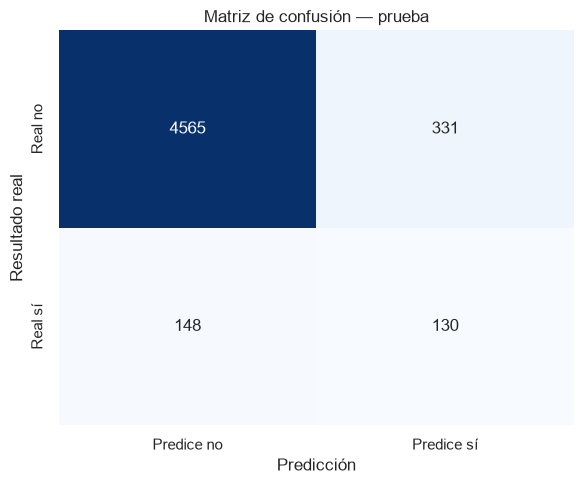

Verdaderos negativos: 4,565
Falsos positivos: 331
Falsos negativos: 148
Verdaderos positivos: 130


In [9]:
matriz = confusion_matrix(y_test, predicciones)
tn, fp, fn, tp = matriz.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Predice no", "Predice sí"],
    yticklabels=["Real no", "Real sí"],
)
plt.title("Matriz de confusión — prueba")
plt.xlabel("Predicción")
plt.ylabel("Resultado real")
plt.tight_layout()
plt.show()

print(f"Verdaderos negativos: {tn:,}")
print(f"Falsos positivos: {fp:,}")
print(f"Falsos negativos: {fn:,}")
print(f"Verdaderos positivos: {tp:,}")

### Interpretación sencilla

- Un **falso negativo** es una desviación real que el modelo no advirtió. Puede permitir que un problema térmico pase inadvertido.
- Un **falso positivo** es una alerta cuando finalmente no hubo desviación. Puede provocar una revisión innecesaria.

Antes de cambiar el umbral, AndinaLog debe decidir cuál de esos costos es más importante. Este notebook conserva el umbral 0,50 y no lo ajusta con los datos de prueba.

## 9. Curvas ROC y precisión-recall

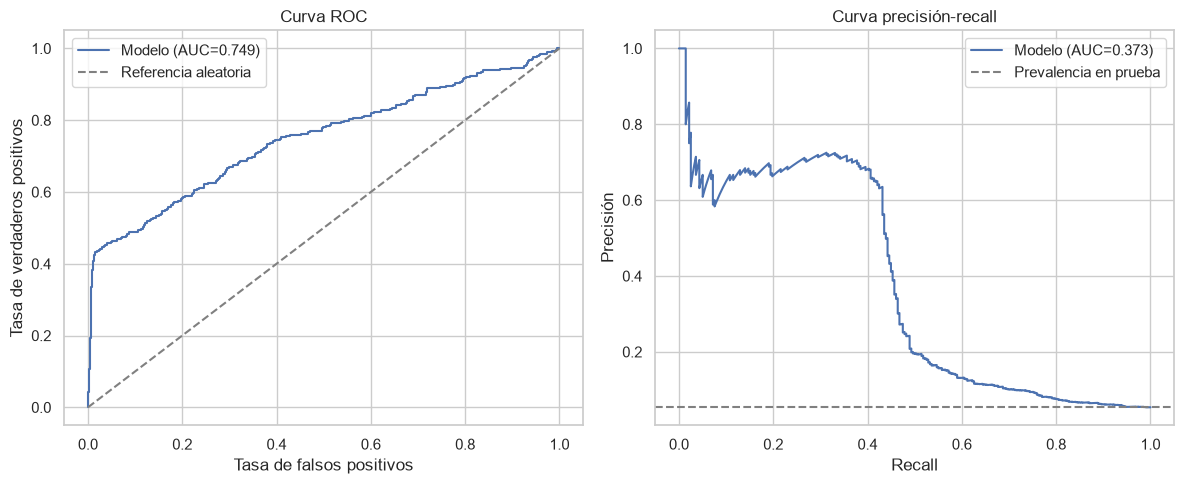

In [10]:
fpr, tpr, _ = roc_curve(y_test, probabilidades)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, probabilidades)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f"Modelo (AUC={metricas.loc['Regresión logística', 'roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Referencia aleatoria")
axes[0].set_title("Curva ROC")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, label=f"Modelo (AUC={metricas.loc['Regresión logística', 'pr_auc']:.3f})")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Prevalencia en prueba")
axes[1].set_title("Curva precisión-recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precisión")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretación sencilla

Las curvas muestran el intercambio entre detectar más desviaciones y generar más falsas alertas. Se presentan para entender el comportamiento del modelo, no para escoger un nuevo umbral usando la prueba.

## 10. Coeficientes del modelo

,predictor,coeficiente_escalado,efecto_en_la_probabilidad
2,desviacion_termica_flag,0.686,aumenta la probabilidad estimada
1,humedad_cabina_pct,0.296,aumenta la probabilidad estimada
0,temperatura_cabina_c,0.176,aumenta la probabilidad estimada
4,variacion_temperatura_30min,-0.018,disminuye la probabilidad estimada
3,temperatura_anterior,-0.364,disminuye la probabilidad estimada


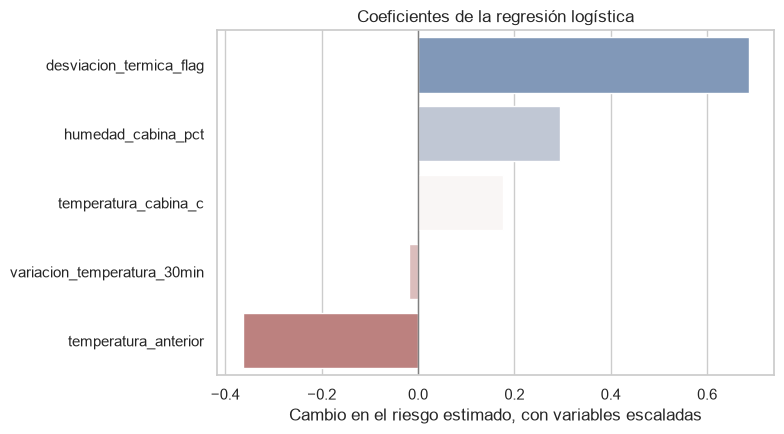

In [11]:
coeficientes = pd.DataFrame({
    "predictor": CONFIG["predictores"],
    "coeficiente_escalado": modelo.named_steps["regresion"].coef_[0],
})
coeficientes["efecto_en_la_probabilidad"] = np.where(
    coeficientes["coeficiente_escalado"] > 0,
    "aumenta la probabilidad estimada",
    "disminuye la probabilidad estimada",
)
coeficientes = coeficientes.sort_values("coeficiente_escalado", ascending=False)
display(coeficientes.round({"coeficiente_escalado": 3}))

plt.figure(figsize=(8, 4.5))
sns.barplot(data=coeficientes, x="coeficiente_escalado", y="predictor", hue="predictor", legend=False, palette="vlag")
plt.axvline(0, color="gray", linewidth=1)
plt.title("Coeficientes de la regresión logística")
plt.xlabel("Cambio en el riesgo estimado, con variables escaladas")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Interpretación sencilla

Un coeficiente positivo empuja la predicción hacia una mayor probabilidad y uno negativo hacia una menor probabilidad, manteniendo constantes las demás variables. Como las variables fueron escaladas, sus magnitudes son comparables.

Estos coeficientes describen asociaciones del modelo; **no demuestran que una variable cause una desviación**.

## 11. Informe y reproducibilidad

In [12]:
informe = f'''# Informe 05 — Regresión logística IoT

## Metodología

- Filas modeladas: {len(modelado):,}
- Entrenamiento: {len(X_train):,} filas y {grupos_train.nunique():,} viajes
- Prueba: {len(X_test):,} filas y {grupos_test.nunique():,} viajes
- Viajes compartidos: {len(viajes_compartidos)}
- Semilla: {CONFIG['semilla']}
- Umbral: {CONFIG['umbral']:.2f}
- Clase positiva en prueba: {y_test.mean() * 100:.2f}%
- Modelo: regresión logística con `class_weight="balanced"`
- Preparación: imputación por mediana y escalado ajustados solo con entrenamiento

## Resultados finales en prueba

- Precisión: {metricas.loc['Regresión logística', 'precision']:.4f}
- Recall: {metricas.loc['Regresión logística', 'recall']:.4f}
- F1: {metricas.loc['Regresión logística', 'f1']:.4f}
- ROC AUC: {metricas.loc['Regresión logística', 'roc_auc']:.4f}
- PR AUC: {metricas.loc['Regresión logística', 'pr_auc']:.4f}
- Verdaderos negativos: {tn:,}
- Falsos positivos: {fp:,}
- Falsos negativos: {fn:,}
- Verdaderos positivos: {tp:,}

## Línea base

La referencia siempre predice la clase 0. Su recall y F1 son 0 porque no identifica ninguna desviación futura.

## Interpretación

El modelo aporta capacidad para ordenar el riesgo y detectar parte de las desviaciones, pero todavía produce falsos negativos y falsos positivos. Cualquier cambio del umbral debe basarse en el costo operativo de ambos errores y evaluarse con validación separada, no con esta prueba final.

## Limitaciones

- La clase positiva es poco frecuente.
- Los coeficientes son asociaciones, no efectos causales.
- El resultado corresponde a una sola división por viaje con semilla fija.
- No se optimizó el umbral con la prueba.

## Reproducibilidad

- Python: {platform.python_version()}
- pandas: {pd.__version__}
- NumPy: {np.__version__}
- scikit-learn: {sklearn.__version__}
- Ejecución UTC: {datetime.now(timezone.utc).isoformat()}
'''

RUTA_INFORME.write_text(informe, encoding="utf-8")
print("Informe generado:", RUTA_INFORME.resolve())

Informe generado: C:\Users\remrodri\Documents\Codex\2026-09-28\referenced-chatgpt-conversation-this-is-an\outputs\05_regresion_logistica_iot\Informe_05_Regresion_Logistica_IoT.md


## 12. Conclusión

La regresión logística supera a la línea base porque sí identifica una parte de las desviaciones futuras. Sin embargo, el modelo no es perfecto: antes de utilizarlo operativamente debe definirse cuánto cuesta omitir una desviación y cuánto cuesta emitir una falsa alerta.